# Conditional Flow-Matching Training

Trains a conditional diffusion model to learn $p(x_{t+1} \mid x_t)$.

**What changes from the unconditional model:**
- Dataset returns consecutive pairs $(x_t, x_{t+1})$ instead of single frames
- `SongUNet` uses `in_channels=4` (2 channels for noisy $z_s$ + 2 channels for conditioning $x_t$ concatenated spatially)
- $x_t$ is passed as `class_labels` — concatenated inside `SongUNet.forward` before the encoder
- Training target is still $x_{t+1} - z_0$ (velocity), same formula as before
- `label_dropout=0.1` enables classifier-free guidance at inference if needed

Everything else (loss structure, optimiser, ODE sampler) is identical to the unconditional case.

## 1. Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from natsort import natsorted
import matplotlib.pyplot as plt
from itertools import islice
import csv

SQG_DIR = Path('SQG')
sys.path.insert(0, str(SQG_DIR))

from diffusion_networks import SongUNet
from dataset import SQGLeadTimeDataset, DATA_1H, DATA_3H


## 2. Config

In [9]:
# ── data ──────────────────────────────────────────────────────────────────
DATA_DIR = DATA_1H   # change to DATA_3H for 3-hour data
DATA_STD = 2660.0    # normalisation std (mean assumed 0)

# ── model ─────────────────────────────────────────────────────────────────
IMG_CHANNELS   = 2    # SQG has 2 vertical levels
IMG_RESOLUTION = 64
FILTERS        = 32
LABEL_DROPOUT  = 0.1

# ── training ──────────────────────────────────────────────────────────────
BATCH_SIZE   = 16
NUM_EPOCHS   = 10
LR           = 1e-3
WEIGHT_DECAY = 1e-4

# ── evaluation ────────────────────────────────────────────────────────────
N_ENSEMBLE    = 10   # ensemble members per rollout
ODE_STEPS     = 100  # Euler steps per ODE solve
N_INIT        = 20   # number of starting points to average metrics over
TRAIN_FRAC    = 0.8  # must match dataset split
MAX_HORIZON    = 100  # must match dataset normalisation constant

# ── misc ──────────────────────────────────────────────────────────────────
SAVE_PATH = Path('../models/best_model_conditional.pth')
LOG_PATH  = Path('../models/training_log.csv')
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Data:   {DATA_DIR}')

Device: cuda
Data:   /home/trace/Documents/Projects/Thesis/data


## 3. Dataset — consecutive pairs $(x_t,\, x_{t+\tau})$

`SQGPairDataset` is imported from `dataset.py`. Switch between 1-hour and 3-hour data by setting `DATA_DIR = DATA_1H` or `DATA_DIR = DATA_3H` in the config above.

In [3]:
train_dataset = SQGLeadTimeDataset(DATA_DIR, std=DATA_STD, split='train')
val_dataset   = SQGLeadTimeDataset(DATA_DIR, std=DATA_STD, split='val')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Pairs — train: {len(train_dataset)}, val: {len(val_dataset)}')

Pairs — train: 8000, val: 2000


## 3.1 Dataset Sanity Check

### Dimension 

### Sample: lead time should be sampled uniformly in each batch
I remember in CEWF there is a mechanism used to sample same lead time in one batch and then shuffle uniformly over batches in epoch so it would ensure for each batch, lead time would be sampled uniformly. Now I want to examine this, you should get all the lead time of some randomly sampled batches and visualize their histogram.

I suspect the mechanism wasn't implemented in dataset.py

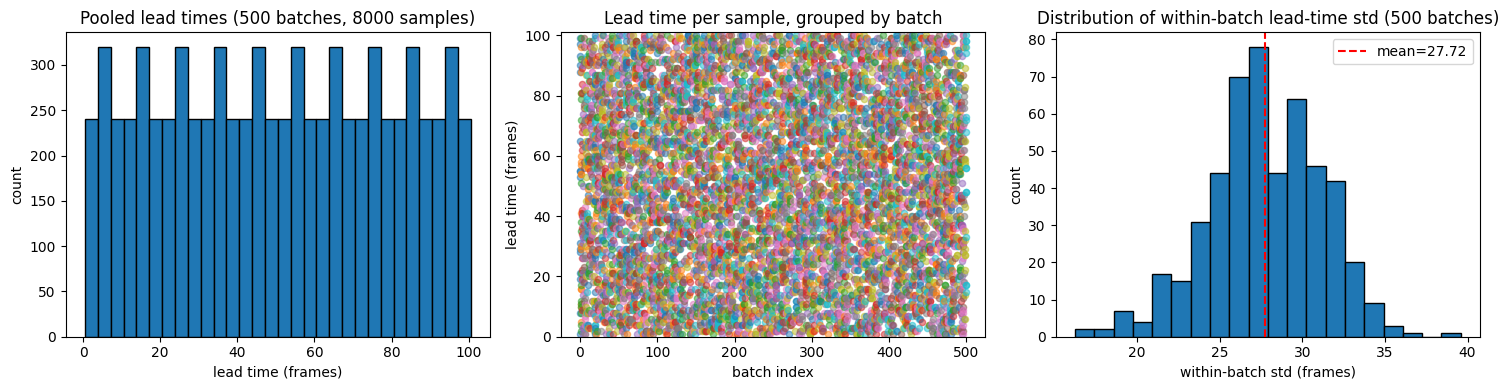

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) pooled lead times -> should be ~uniform over [1, n_leads] frames
all_leads = np.concatenate(batch_leads)
axes[0].hist(all_leads, bins=min(n_leads, 30), range=(0.5, n_leads + 0.5),
             edgecolor='black')
axes[0].set_xlabel('lead time (frames)')
axes[0].set_ylabel('count')
axes[0].set_title(f'Pooled lead times ({n_collected} batches, {all_leads.size} samples)')

# (b) per-sample lead time grouped by batch -> reveals within-batch structure
for bi, lb in enumerate(batch_leads):
    axes[1].scatter(np.full_like(lb, bi), lb, alpha=0.5, s=20)
axes[1].set_xlabel('batch index')
axes[1].set_ylabel('lead time (frames)')
axes[1].set_title('Lead time per sample, grouped by batch')
axes[1].set_ylim(0, n_leads + 1)
if n_leads <= 20:
    axes[1].set_yticks(range(1, n_leads + 1))

# (c) histogram of within-batch standard deviation
axes[2].hist(within_batch_std, bins=20, edgecolor='black')
axes[2].set_xlabel('within-batch std (frames)')
axes[2].set_ylabel('count')
axes[2].set_title(f'Distribution of within-batch lead-time std ({n_collected} batches)')
axes[2].axvline(within_batch_std.mean(), color='red', linestyle='--', 
                label=f'mean={within_batch_std.mean():.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()

You haven't figured out how the batch would be formed in this new dataset, keep it in your mind.

## 4. Model

The only architectural change from the unconditional model is `in_channels=4`.

Inside `SongUNet.forward`, when `class_labels` is provided it is concatenated
channel-wise onto the noisy input `z_s` before the encoder:

`[z_s (2ch)] cat [x_t (2ch)]  →  [4ch input to encoder]`

The network therefore sees the full spatial structure of $x_t$ at every location
while learning the velocity toward $x_{t+1}$.

In [5]:
model = SongUNet(
    img_resolution     = IMG_RESOLUTION,
    in_channels        = IMG_CHANNELS * 2,  # 2 (noisy z_s) + 2 (x_t conditioning)
    out_channels       = IMG_CHANNELS,      # velocity has same shape as x_{t+1}
    embedding_type     = 'fourier',
    encoder_type       = 'residual',
    decoder_type       = 'standard',
    channel_mult_noise = 2,
    resample_filter    = [1, 3, 3, 1],
    model_channels     = FILTERS,
    channel_mult       = [2, 2, 2],
    attn_resolutions   = [32],
    label_dropout      = LABEL_DROPOUT,
    time_emb           = 1 
).to(device)

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 3,543,778


## 5. Flow-Matching Loss

Interpolant:  $z_s = (1 - s)\,z_0 + s\,x_{t+1}$, $\quad s \sim \text{Uniform}[0,1]$, $\quad z_0 \sim \mathcal{N}(0, I)$

Velocity target:  $\dot{z}_s = x_{t+1} - z_0$  (constant along the linear path)

Loss:  $\mathcal{L} = \mathbb{E}\bigl[\|\hat{b}(z_s,\, s,\, x_t) - (x_{t+1} - z_0)\|^2\bigr]$

The formula is identical to the unconditional case — the only difference
is that the model now also receives $x_t$ as spatial conditioning.

In [6]:
def flow_matching_loss(model, x_t, x_t1, lead_time):
    """
    Conditional flow-matching loss for one batch.

    Args:
        model : SongUNet with in_channels = 2*C
        x_t   : current state  (B, C, H, W)  — the conditioning input
        x_t1  : next state     (B, C, H, W)  — the generation target
        lead_time   : lead time (hours)

    Returns:
        scalar loss
    """
    B = x_t1.shape[0]

    # sample interpolant time s ~ Uniform[0, 1]
    s         = torch.rand(B, device=x_t1.device)       # (B,)
    s_spatial = s.view(B, 1, 1, 1)                      # broadcast over C, H, W

    # sample base noise
    z0 = torch.randn_like(x_t1)                         # (B, C, H, W)

    # form interpolated noisy sample at time s
    z_s = (1 - s_spatial) * z0 + s_spatial * x_t1       # (B, C, H, W)

    # target velocity (same at every s along the linear path)
    target = x_t1 - z0                                  # (B, C, H, W)

    # model prediction
    # noise_labels = s   (interpolant time plays the role of noise level)
    # class_labels = x_t (spatially concatenated inside SongUNet before the encoder)
    pred = model(z_s, s, class_labels=x_t, time_labels=lead_time)              # (B, C, H, W)

    return ((pred - target) ** 2).mean()

## 6. Optimiser

In [7]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# cosine decay: learning rate decreases smoothly over training
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# linear warmup for the first 500 steps: avoids large unstable updates at the start
warmup = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=500)

## 7. Training Loop

In [10]:
train_losses, val_losses = [], []
best_val_loss = float('inf')

# sanity check code 
# only train with 1/10 data
MAX_BATCHES = len(train_loader) // 10

with open(LOG_PATH, 'w', newline='') as f:
    csv.writer(f).writerow(['epoch', 'train_loss', 'val_loss'])

for epoch in range(NUM_EPOCHS):

    # ── training phase ────────────────────────────────────────────────────DATA_STD
    model.train()
    total_train = 0.0
    # for x_t, x_t1, lead_time in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [train]', leave=False):
    for x_t, x_t1, lead_time in tqdm(
        islice(train_loader, MAX_BATCHES),   # ← only change
        total=MAX_BATCHES,
        desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [train]',
        leave=False
    ):  # check code
        # if epoch == 0 and total_train == 0.0:
        #     print(x_t.shape, x_t1.shape, lead_time.shape)
        #     print(f'Lead time range in batch: {lead_time.min().item()} to {lead_time.max().item()} hours')
        
        x_t  = x_t.to(device)
        x_t1 = x_t1.to(device)
        lead_time = lead_time.to(device)

        optimizer.zero_grad()
        loss = flow_matching_loss(model, x_t, x_t1, lead_time)
        loss.backward()
        optimizer.step()
        warmup.step()   # warmup steps per batch, not per epoch

        total_train += loss.item()

    avg_train = total_train / len(train_loader)

    # ── validation phase ──────────────────────────────────────────────────
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for x_t, x_t1, lead_time in val_loader:
            x_t  = x_t.to(device)
            x_t1 = x_t1.to(device)
            lead_time = lead_time.to(device)
            total_val += flow_matching_loss(model, x_t, x_t1, lead_time).item()

    avg_val = total_val / len(val_loader)

    # ── bookkeeping ───────────────────────────────────────────────────────
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    scheduler.step()   # cosine decay steps per epoch

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), SAVE_PATH)
        tag = '  <- best'
    else:
        tag = ''

    with open(LOG_PATH, 'a', newline='') as f:
        csv.writer(f).writerow([epoch + 1, avg_train, avg_val])

    print(f'Epoch {epoch+1:3d}  train={avg_train:.4f}  val={avg_val:.4f}{tag}')

print(f'\nTraining done. Best val loss: {best_val_loss:.4f}')


Epoch   1  train=0.1435  val=1.4185  <- best


Epoch   2  train=0.1416  val=1.1727  <- best


Epoch   3  train=0.1198  val=1.1718  <- best


Epoch   4  train=0.0998  val=0.8521  <- best


Epoch   5  train=0.0882  val=0.8415  <- best


Epoch   6  train=0.0911  val=0.8156  <- best


Epoch   7  train=0.0840  val=0.8160


Epoch   8  train=0.0832  val=0.7803  <- best


Epoch   9  train=0.0797  val=0.7876


Epoch  10  train=0.0804  val=0.7744  <- best

Training done. Best val loss: 0.7744


## 8. Loss Curves

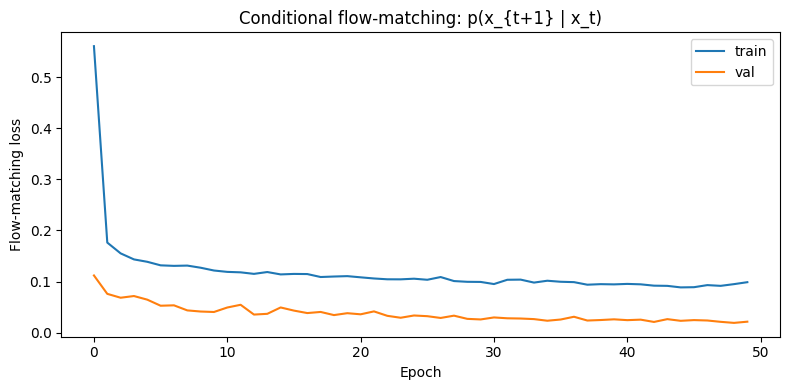

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses,   label='val')
plt.xlabel('Epoch')
plt.ylabel('Flow-matching loss')
plt.title('Conditional flow-matching: p(x_{t+1} | x_t)')
plt.legend()
plt.tight_layout()
plt.show()